In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [11]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [12]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [19]:
model = keras.Sequential(
  [
    keras.Input(shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer1"),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
  ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
y = model(X)
print(y[149])

tf.Tensor([0.5589424  0.55825007 0.56301135], shape=(3,), dtype=float32)


In [15]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2732  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2721 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2711 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2700 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2690 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2680 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2670 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2661 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2652 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2642 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2633 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2625 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2616 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2608 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2599 
Epoch 16/500
5/5 ━

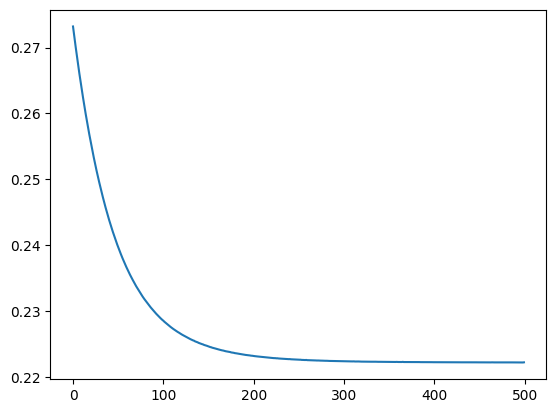

In [16]:
plt.plot(history.history['loss'])
plt.show()

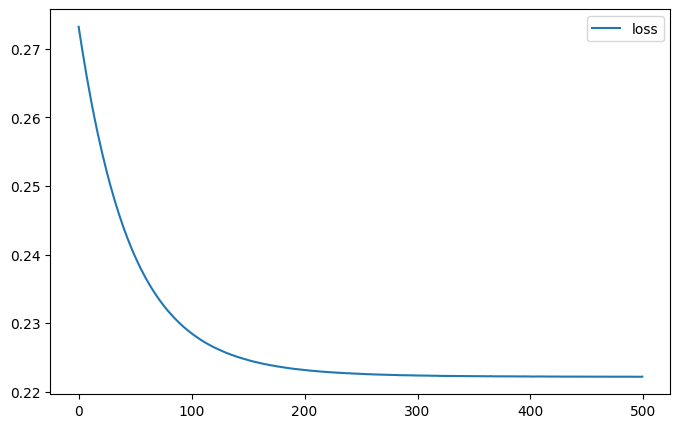

In [17]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [18]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[0.3363723 , 0.33632177, 0.33537084]], dtype=float32)

## Arquitectura de la Red Neuronal

La red neuronal es un modelo secuencial de Keras con las siguientes capas:

*   **Capa 1 (layer1):** Una capa `Dense` (totalmente conectada) con 3 unidades y función de activación 'sigmoid'. Espera una forma de entrada de (4,).
*   **Capa 2 (layer2):** Una capa `Dense` con 3 unidades y función de activación 'sigmoid'.
*   **Capa 3 (layer3):** Una capa `Dense` con 3 unidades y función de activación 'sigmoid'.
*   **Capa 4 (layer4):** Una capa `Dense` con 3 unidades y función de activación 'sigmoid'.

Este modelo está diseñado para clasificar las 4 características de entrada en 3 posibles clases de salida, utilizando activaciones sigmoid en todas las capas para una salida entre 0 y 1.

## Reporte Detallado del Modelo Keras

Este modelo de red neuronal se ha construido utilizando la API `Sequential` de Keras, lo que indica una pila lineal de capas.

### Topology (Topología)

El modelo consiste en las siguientes capas, organizadas secuencialmente:

1.  **Capa de Entrada (`keras.Input`):** Define la forma de los datos de entrada al modelo. En este caso, `shape=(4,)` indica que cada muestra de entrada es un vector de 4 características (correspondiente a las 4 características del conjunto de datos Iris: longitud del sépalo, ancho del sépalo, longitud del pétalo, ancho del pétalo).
2.  **Capa Densa 1 (`layer1`):** Una capa `Dense` con 3 unidades (neuronas) y una función de activación `sigmoid`. Esta capa recibe las 4 características de entrada y produce 3 salidas.
3.  **Capa Densa 2 (`layer2`):** Otra capa `Dense` con 3 unidades y activación `sigmoid`. Recibe las 3 salidas de la capa anterior y produce 3 nuevas salidas.
4.  **Capa Densa 3 (`layer3`):** Similar a la anterior, una capa `Dense` con 3 unidades y activación `sigmoid`.
5.  **Capa Densa 4 (`layer4`):** La última capa `Dense`, también con 3 unidades y activación `sigmoid`. Esta capa es la capa de salida final del modelo, produciendo 3 valores que pueden interpretarse como probabilidades para las 3 clases (especies de Iris).

Cada capa `Dense` aplica una transformación lineal a sus entradas ($Z = XW + b$) seguida de una función de activación no lineal (en este caso, la sigmoide $A = \text{sigmoid}(Z)$).

### Weight Initialization (Inicialización de Pesos)

La inicialización de los pesos (matrices de pesos $W$ y vectores de sesgo $b$) es un paso crucial para el entrenamiento efectivo de las redes neuronales. Una mala inicialización puede llevar a problemas como gradientes desvanecidos o explosivos.

*   **Keras (por defecto):** Cuando defines una capa `Dense` en Keras y no especificas explícitamente un inicializador de pesos (`kernel_initializer`) o de sesgos (`bias_initializer`), Keras utiliza inicializadores predeterminados que han demostrado ser efectivos para la mayoría de los casos. Para la capa `Dense`, el `kernel_initializer` predeterminado suele ser `GlorotUniform` (también conocido como Xavier uniform initializer) y el `bias_initializer` suele ser `zeros` (inicializando los sesgos a cero).
    *   `GlorotUniform` selecciona muestras aleatorias de una distribución uniforme dentro de un rango determinado por el número de entradas y salidas de la capa, lo que ayuda a mantener las varianzas de las activaciones y los gradientes en un nivel saludable a través de la red, facilitando un entrenamiento más estable.
    *   Inicializar los sesgos a cero es una práctica común y segura, ya que los sesgos pueden aprenderse rápidamente a partir de los gradientes durante el entrenamiento.

*   **Implementación Manual:** En una implementación manual, el desarrollador tendría que escribir código explícito para generar estos valores aleatorios o ceros para cada matriz de pesos y vector de sesgos de cada capa, asegurándose de que sigan distribuciones y rangos adecuados, lo cual es propenso a errores y requiere un conocimiento profundo de los principios de inicialización.

### Forward Propagation (Propagación Hacia Adelante)

La propagación hacia adelante es el proceso por el cual los datos de entrada pasan a través de la red neuronal, capa por capa, para producir una salida.

*   **Keras:** Keras automatiza completamente este proceso. Una vez que el modelo está definido, llamar a `model(X)` o `model.predict(X)` para nuevas entradas ejecuta la propagación hacia adelante. Internamente, Keras gestiona la aplicación secuencial de las operaciones de cada capa: primero la multiplicación de la matriz de entrada con los pesos de la capa, la suma de los sesgos y luego la aplicación de la función de activación. No necesitamos preocuparnos por las matemáticas de bajo nivel.

*   **Implementación Manual:** En una implementación manual, tendrías que codificar explícitamente cada paso: para cada capa, calcular $Z = XW + b$ usando operaciones de álgebra lineal (multiplicaciones de matrices y sumas de vectores), y luego aplicar la función `sigmoid` elemento a elemento. Esto se repetiría para cada capa de la red, pasando la salida de una capa como entrada a la siguiente.

### Training (Entrenamiento)

El entrenamiento implica ajustar los pesos y sesgos del modelo para minimizar una función de pérdida (error) entre las predicciones del modelo y las etiquetas verdaderas, utilizando un optimizador.

*   **Keras:** El proceso de entrenamiento en Keras se simplifica enormemente con el método `model.compile()` y `model.fit()`.
    *   **Compilación:** Se definió el optimizador como `tf.keras.optimizers.SGD(learning_rate=0.03)`, que es el algoritmo de descenso de gradiente estocástico con una tasa de aprendizaje de 0.03. La función de pérdida es `tf.keras.losses.MeanSquaredError()`, que mide la media de los cuadrados de las diferencias entre las predicciones y los valores reales. Al llamar a `model.compile(optimizer, loss)`, Keras prepara el modelo para el entrenamiento.
    *   **Ajuste (`model.fit`):** La llamada a `history = model.fit(X, Y, epochs=500)` inicia el entrenamiento. Durante cada época, el modelo realiza los siguientes pasos internamente:
        1.  **Propagación hacia adelante:** Las entradas `X` pasan a través de la red para generar las predicciones `y_pred`.
        2.  **Cálculo de la Pérdida:** Se calcula el valor de la `MeanSquaredError` entre `y_pred` y las etiquetas `Y`.
        3.  **Backpropagation (Propagación Hacia Atrás):** Este es un paso crítico. Keras (a través de TensorFlow y su sistema de diferenciación automática, `tf.GradientTape`) calcula automáticamente los gradientes de la función de pérdida con respecto a cada peso y sesgo en la red. No se requiere que el usuario derive o implemente estas ecuaciones de gradiente. Este es un proceso extremadamente complejo en redes profundas.
        4.  **Actualización de Pesos:** El optimizador `SGD` utiliza estos gradientes calculados para ajustar los pesos y sesgos del modelo de una manera que reduce la función de pérdida. La fórmula básica de actualización para SGD es $W = W - \alpha \nabla L$, donde $\alpha$ es la tasa de aprendizaje y $\nabla L$ es el gradiente de la pérdida.

*   **Implementación Manual:** Una implementación manual del entrenamiento implicaría:
    *   Derivar manualmente las ecuaciones para los gradientes de la función de pérdida con respecto a cada peso y sesgo en cada capa (un proceso matemáticamente intensivo y propenso a errores).
    *   Codificar estas ecuaciones.
    *   Implementar un bucle de entrenamiento que realice la propagación hacia adelante, calcule la pérdida, aplique las ecuaciones de backpropagation para obtener los gradientes y luego actualice manualmente cada peso y sesgo utilizando el optimizador elegido. Esto requiere un control granular y una comprensión profunda de todos los aspectos matemáticos y algorítmicos.